<a href="https://colab.research.google.com/github/Suryansh87suman/Car-Market-Trends-Analysis-with-Car-Dekho-Data/blob/main/Car_Market_Trends_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as nd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv")

In [3]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [5]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [20]:
duplicate_count = df.duplicated().sum()
print('Duplicate Rows',duplicate_count)

Duplicate Rows 1


In [21]:
df = df.drop_duplicates().copy()
print('Duplicates remaining',df.duplicated().sum())

Duplicates remaining 0


In [22]:
df.columns.to_list()

['Car_Name',
 'Year',
 'Selling_Price',
 'Present_Price',
 'Kms_Driven',
 'Fuel_Type',
 'Seller_Type',
 'Transmission',
 'Owner']

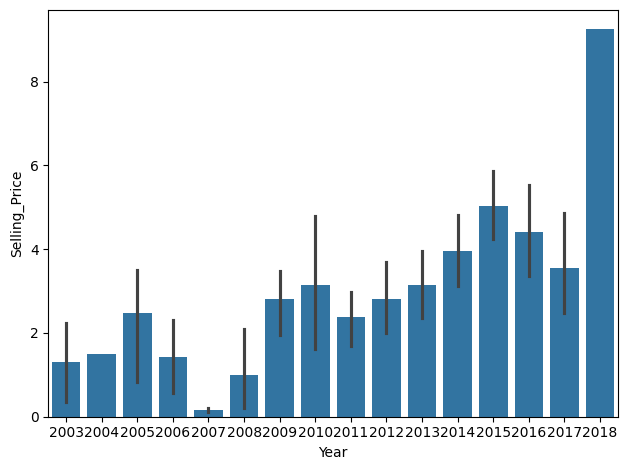

In [23]:
sns.barplot(x="Year",y="Selling_Price",data=df)
plt.tight_layout()
plt.show()

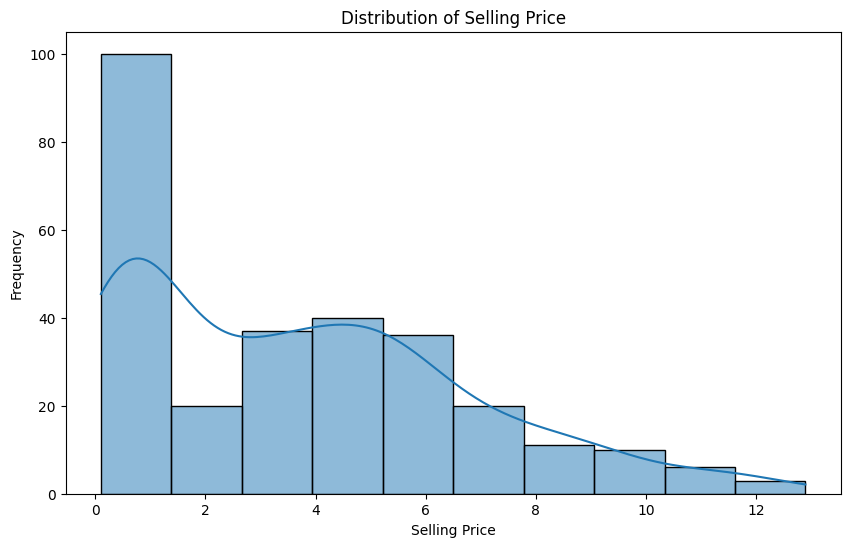

In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Selling_Price'], kde=True)
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.show()

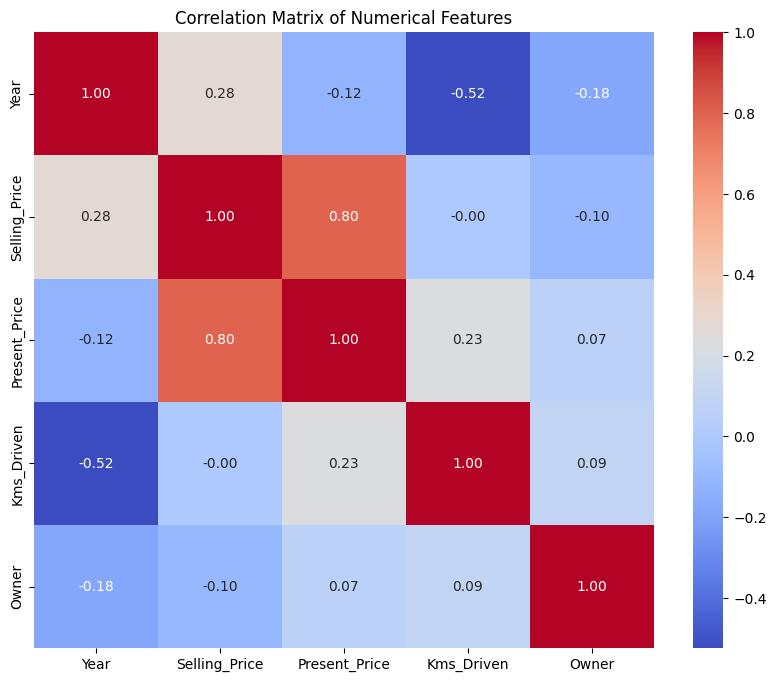

In [25]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

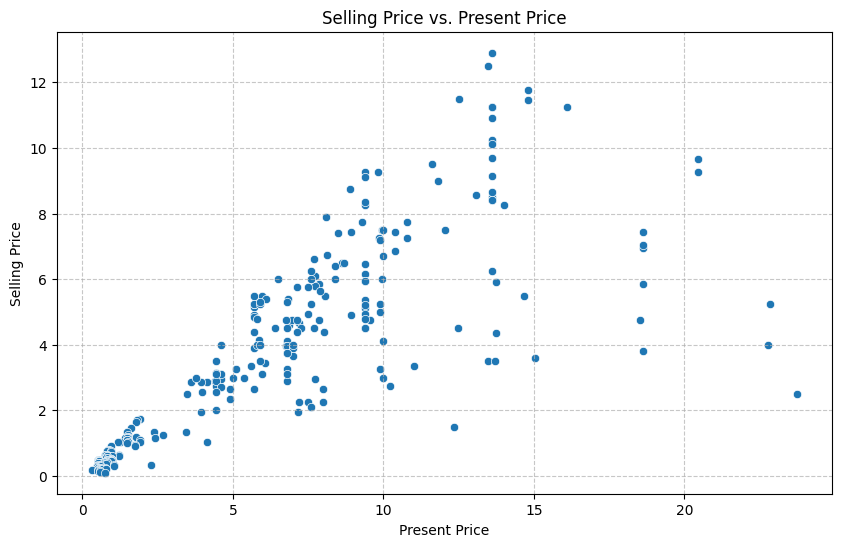

In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Present_Price', y='Selling_Price', data=df)
plt.title('Selling Price vs. Present Price')
plt.xlabel('Present Price')
plt.ylabel('Selling Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [27]:
mean_selling_price_by_fuel_type = df.groupby('Fuel_Type')['Selling_Price'].mean()
display(mean_selling_price_by_fuel_type)

,Selling_Price
Fuel_Type,
CNG,3.100000
Diesel,6.907556
Petrol,3.089576


/tmp/ipykernel_1573/1648342091.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_selling_price_by_fuel_type.index, y=mean_selling_price_by_fuel_type.values, palette='viridis')


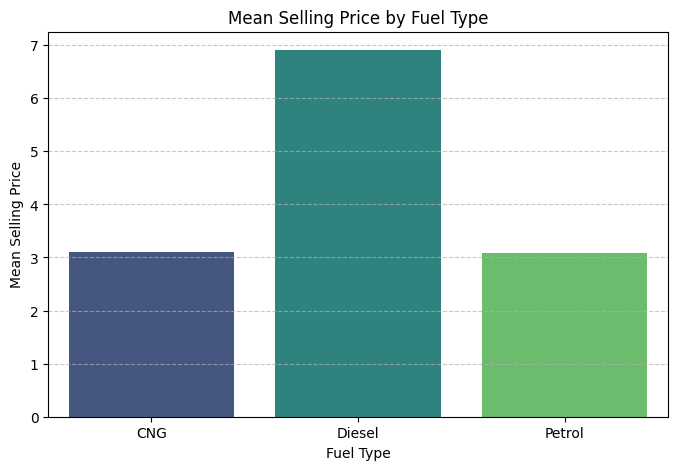

In [28]:
plt.figure(figsize=(8, 5))
sns.barplot(x=mean_selling_price_by_fuel_type.index, y=mean_selling_price_by_fuel_type.values, palette='viridis')
plt.title('Mean Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Mean Selling Price')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [29]:
display(df['Selling_Price'].describe())

,Selling_Price
count,283.000000
mean,3.696749
std,3.046136
min,0.100000
25%,0.750000
50%,3.250000
75%,5.500000
max,12.900000


/tmp/ipykernel_1573/1388890131.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Seller_Type', y='Selling_Price', data=df, palette='pastel')


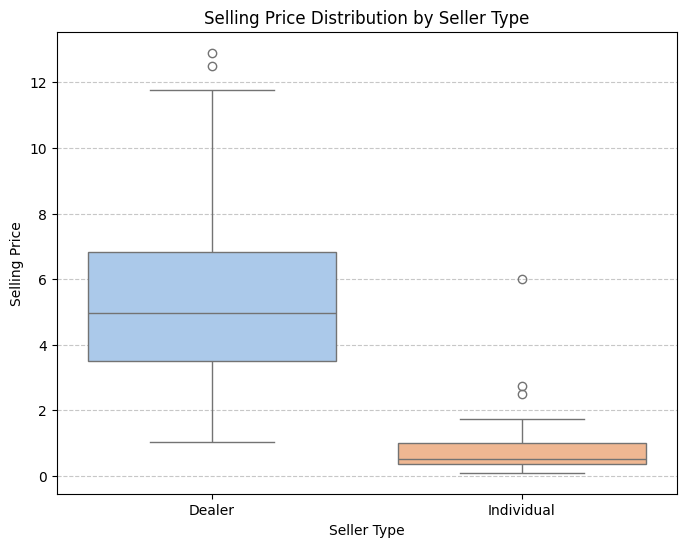

In [30]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Seller_Type', y='Selling_Price', data=df, palette='pastel')
plt.title('Selling Price Distribution by Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Selling Price')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

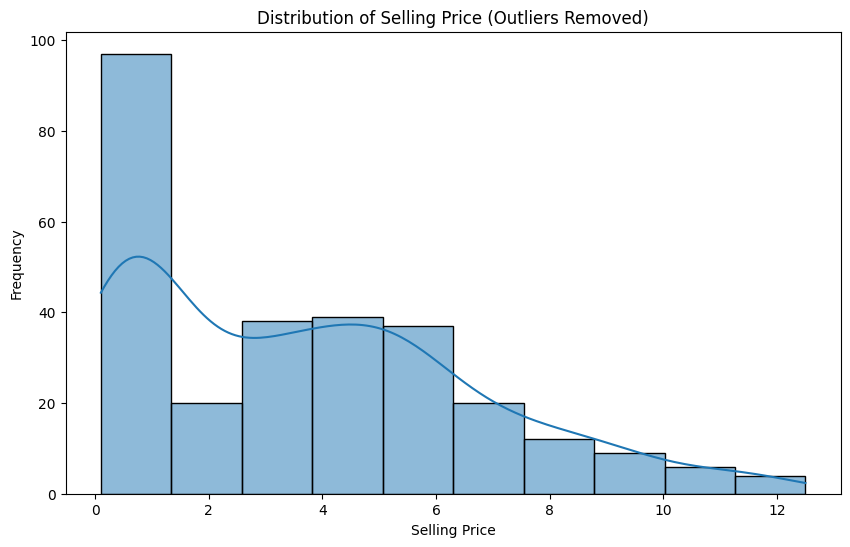

In [34]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Selling_Price'], kde=True)
plt.title('Distribution of Selling Price (Outliers Removed)')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.show()

### Relationship between 'Selling_Price' and 'Transmission'

/tmp/ipykernel_1573/2195342748.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Transmission', y='Selling_Price', data=df, palette='viridis')


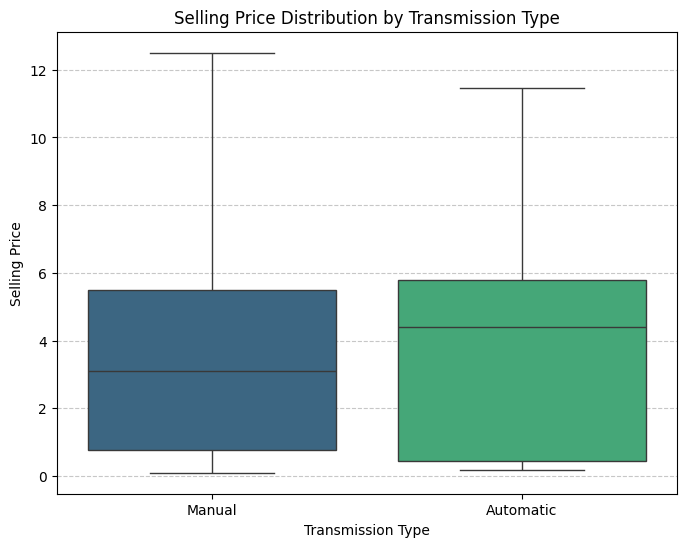

In [35]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Transmission', y='Selling_Price', data=df, palette='viridis')
plt.title('Selling Price Distribution by Transmission Type')
plt.xlabel('Transmission Type')
plt.ylabel('Selling Price')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Combined Visualizations

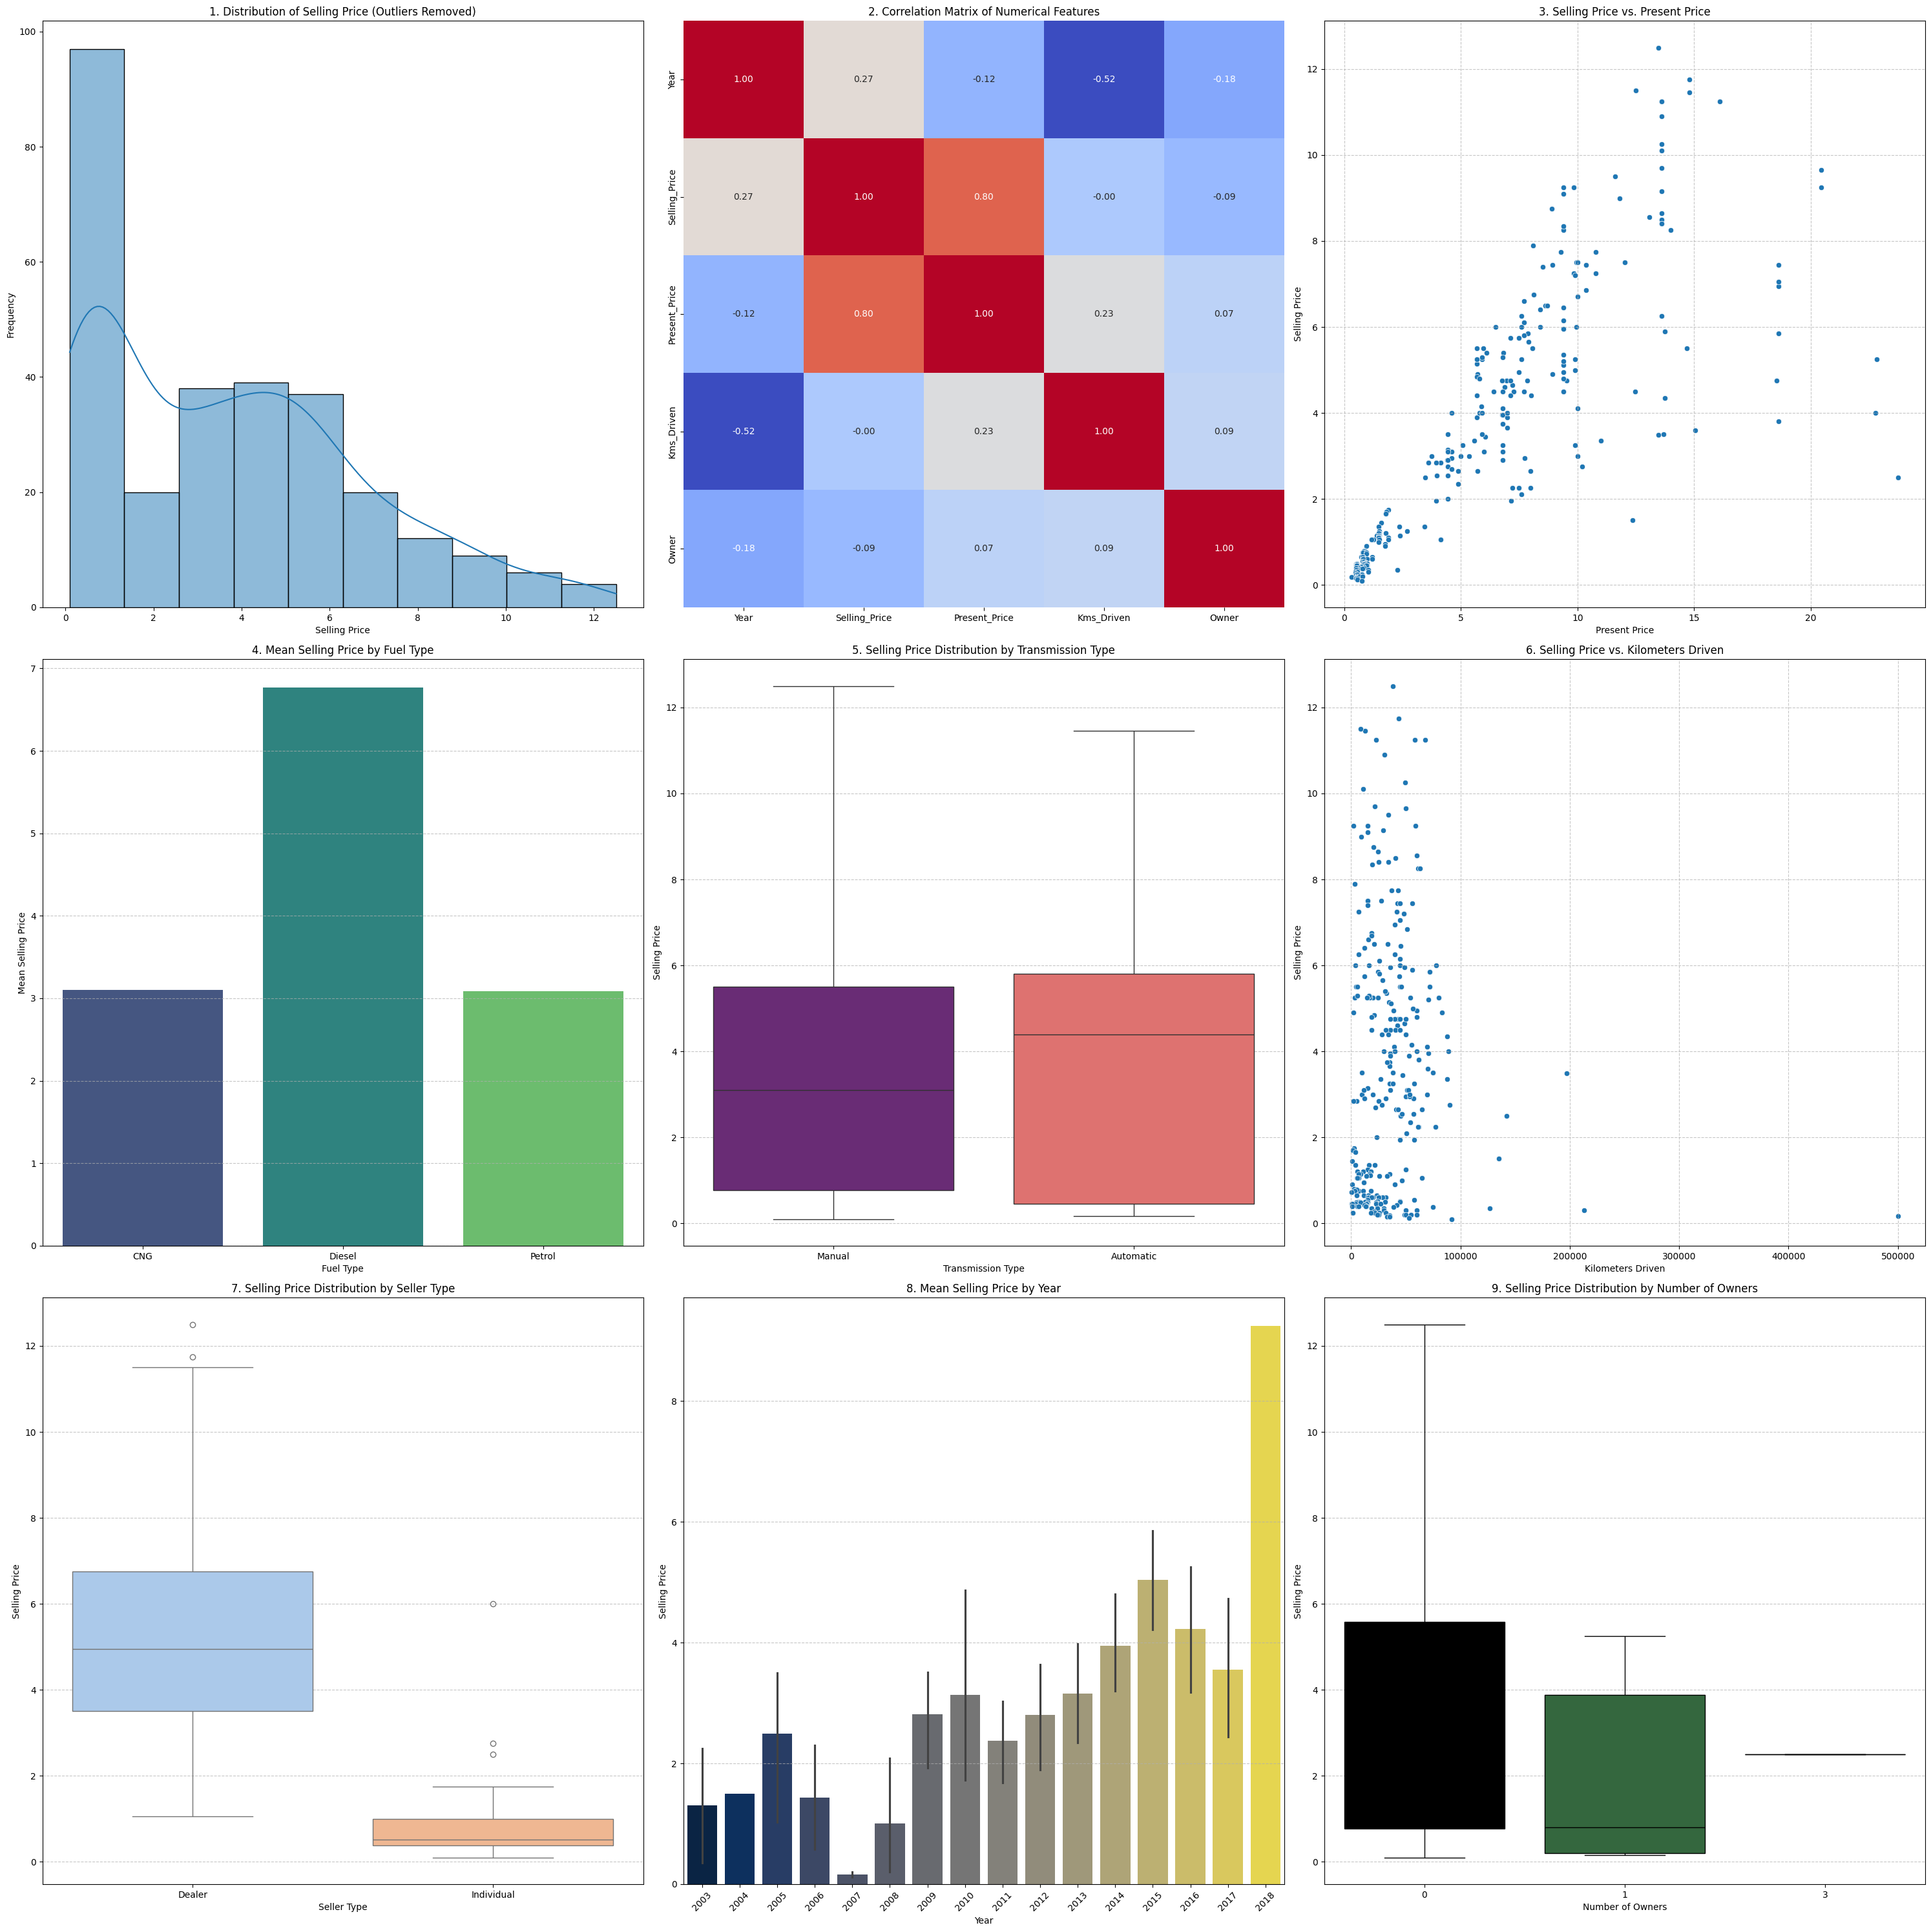

In [42]:
plt.figure(figsize=(30, 30)) # Figure size adjusted for 3x3 grid

# Group 1: Overall Market Overview & Key Price Drivers
# 1. Histogram of Selling Price (Outliers Removed)
plt.subplot(3, 3, 1) # 3 rows, 3 columns, 1st plot
sns.histplot(df['Selling_Price'], kde=True)
plt.title('1. Distribution of Selling Price (Outliers Removed)')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')

# 2. Correlation Matrix of Numerical Features
plt.subplot(3, 3, 2) # 3 rows, 3 columns, 2nd plot
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=False)
plt.title('2. Correlation Matrix of Numerical Features')

# 3. Selling Price vs. Present Price (Scatter plot)
plt.subplot(3, 3, 3) # 3 rows, 3 columns, 3rd plot
sns.scatterplot(x='Present_Price', y='Selling_Price', data=df)
plt.title('3. Selling Price vs. Present Price')
plt.xlabel('Present Price')
plt.ylabel('Selling Price')
plt.grid(True, linestyle='--', alpha=0.7)

# Group 2: Car Specifications & Usage Impact
# 4. Mean Selling Price by Fuel Type (Bar plot)
plt.subplot(3, 3, 4) # 3 rows, 3 columns, 4th plot
mean_selling_price_by_fuel_type = df.groupby('Fuel_Type')['Selling_Price'].mean()
sns.barplot(x=mean_selling_price_by_fuel_type.index, y=mean_selling_price_by_fuel_type.values, palette='viridis', hue=mean_selling_price_by_fuel_type.index, legend=False)
plt.title('4. Mean Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Mean Selling Price')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Selling Price Distribution by Transmission Type (Box plot)
plt.subplot(3, 3, 5) # 3 rows, 3 columns, 5th plot
sns.boxplot(x='Transmission', y='Selling_Price', data=df, palette='magma', hue='Transmission', legend=False)
plt.title('5. Selling Price Distribution by Transmission Type')
plt.xlabel('Transmission Type')
plt.ylabel('Selling Price')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 6. Selling Price vs. Kilometers Driven (Scatter Plot)
plt.subplot(3, 3, 6) # 3 rows, 3 columns, 6th plot
sns.scatterplot(x='Kms_Driven', y='Selling_Price', data=df)
plt.title('6. Selling Price vs. Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price')
plt.grid(True, linestyle='--', alpha=0.7)

# Group 3: Ownership & Depreciation Factors
# 7. Selling Price Distribution by Seller Type (Box plot)
plt.subplot(3, 3, 7) # 3 rows, 3 columns, 7th plot
sns.boxplot(x='Seller_Type', y='Selling_Price', data=df, palette='pastel', hue='Seller_Type', legend=False)
plt.title('7. Selling Price Distribution by Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Selling Price')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 8. Mean Selling Price by Year (Bar plot)
plt.subplot(3, 3, 8) # 3 rows, 3 columns, 8th plot
sns.barplot(x='Year', y='Selling_Price', data=df, palette='cividis', hue='Year', legend=False)
plt.title('8. Mean Selling Price by Year')
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 9. Selling Price Distribution by Number of Owners (Box Plot)
plt.subplot(3, 3, 9) # 3 rows, 3 columns, 9th plot
sns.boxplot(x='Owner', y='Selling_Price', data=df, palette='cubehelix', hue='Owner', legend=False)
plt.title('9. Selling Price Distribution by Number of Owners')
plt.xlabel('Number of Owners')
plt.ylabel('Selling Price')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Group 1: Overall Market Overview & Key Price Drivers

#### 1. Distribution of Selling Price (Outliers Removed)

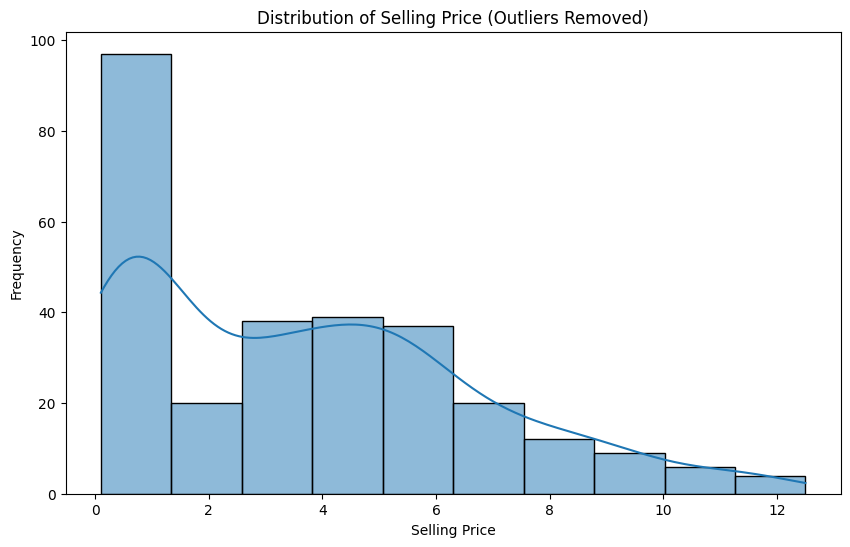

In [43]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Selling_Price'], kde=True)
plt.title('Distribution of Selling Price (Outliers Removed)')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.show()

#### 2. Correlation Matrix of Numerical Features

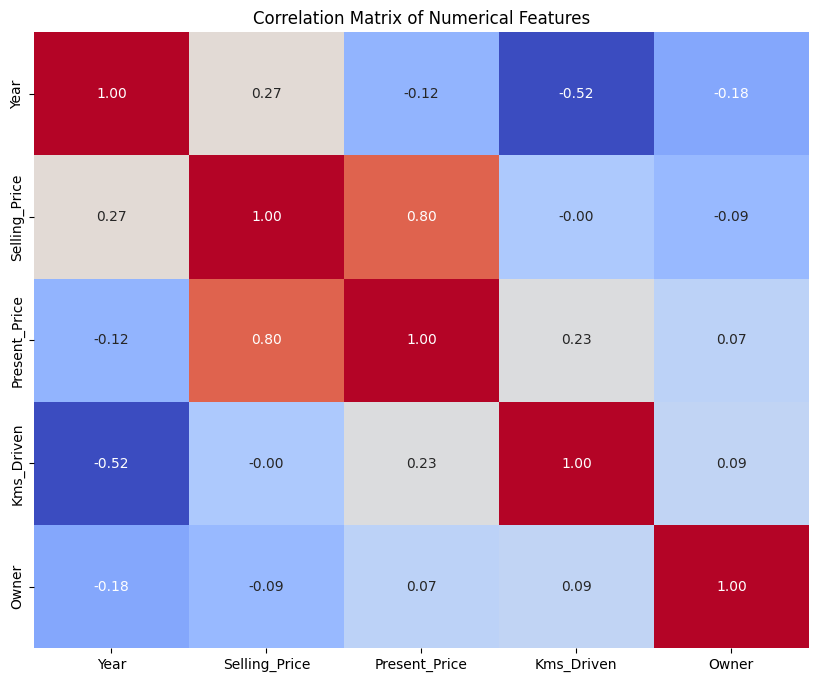

In [44]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=False)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

#### 3. Selling Price vs. Present Price

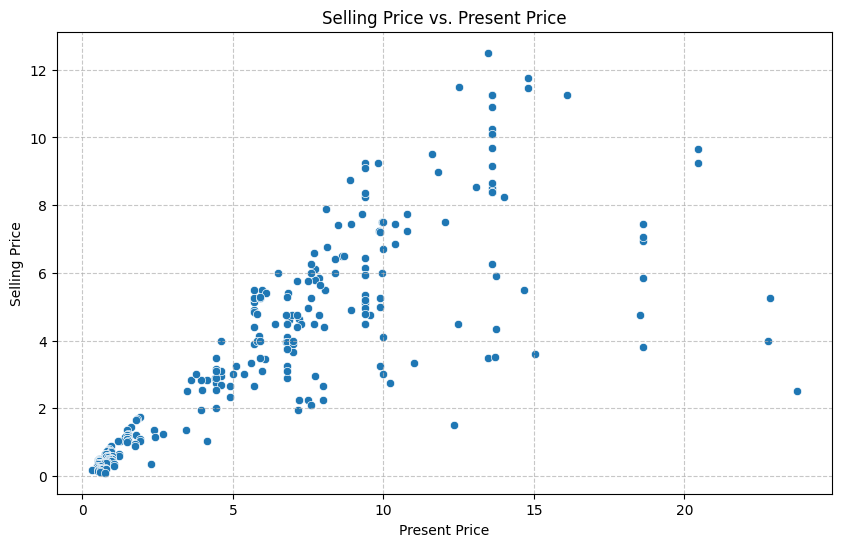

In [45]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Present_Price', y='Selling_Price', data=df)
plt.title('Selling Price vs. Present Price')
plt.xlabel('Present Price')
plt.ylabel('Selling Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Group 2: Car Specifications & Usage Impact

#### 4. Mean Selling Price by Fuel Type

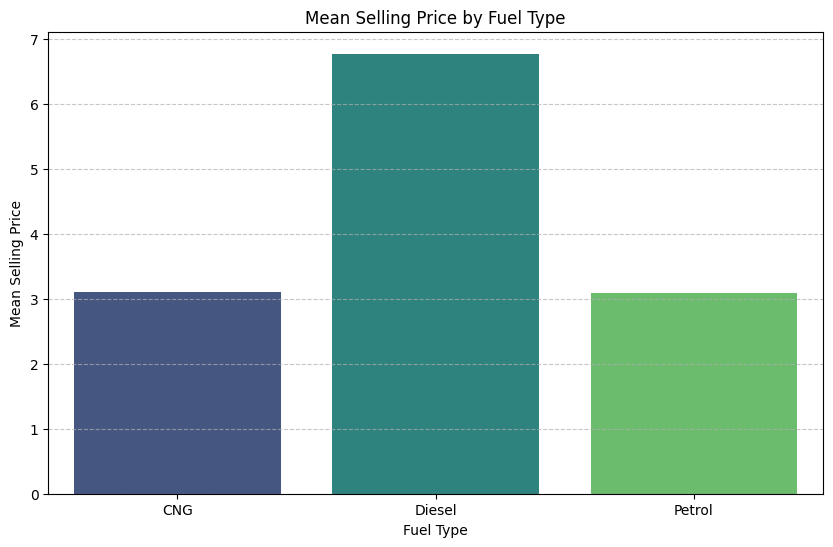

In [46]:
mean_selling_price_by_fuel_type = df.groupby('Fuel_Type')['Selling_Price'].mean()

plt.figure(figsize=(10, 6))
sns.barplot(x=mean_selling_price_by_fuel_type.index, y=mean_selling_price_by_fuel_type.values, palette='viridis', hue=mean_selling_price_by_fuel_type.index, legend=False)
plt.title('Mean Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Mean Selling Price')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### 5. Selling Price Distribution by Transmission Type

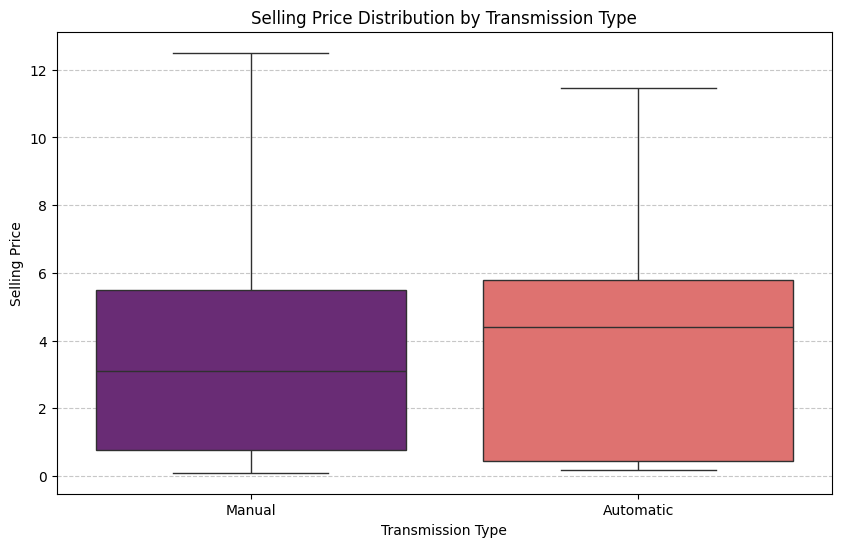

In [47]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Transmission', y='Selling_Price', data=df, palette='magma', hue='Transmission', legend=False)
plt.title('Selling Price Distribution by Transmission Type')
plt.xlabel('Transmission Type')
plt.ylabel('Selling Price')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### 6. Selling Price vs. Kilometers Driven

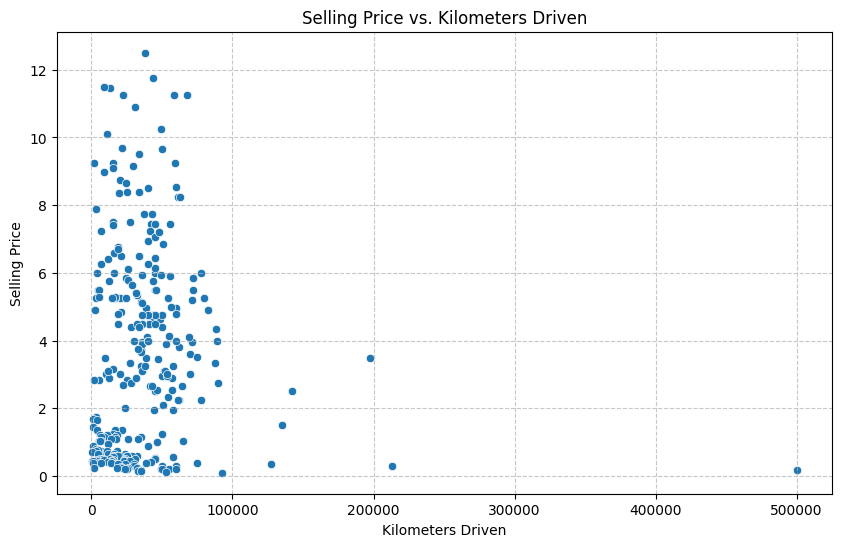

In [48]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Kms_Driven', y='Selling_Price', data=df)
plt.title('Selling Price vs. Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Group 3: Ownership & Depreciation Factors

#### 7. Selling Price Distribution by Seller Type

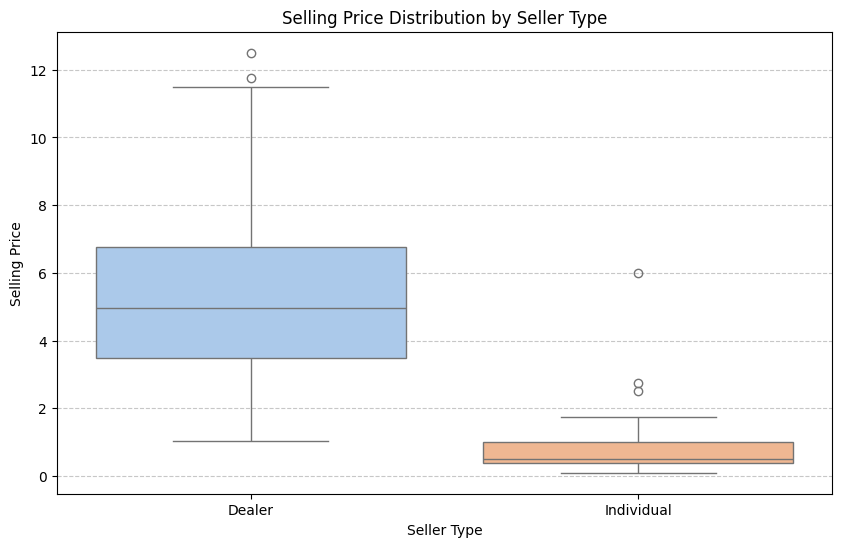

In [49]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Seller_Type', y='Selling_Price', data=df, palette='pastel', hue='Seller_Type', legend=False)
plt.title('Selling Price Distribution by Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Selling Price')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### 8. Mean Selling Price by Year

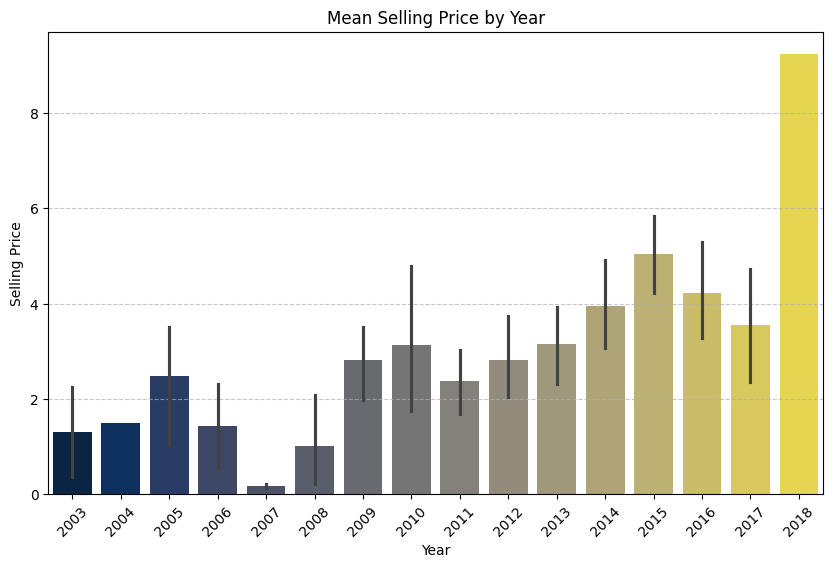

In [50]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Year', y='Selling_Price', data=df, palette='cividis', hue='Year', legend=False)
plt.title('Mean Selling Price by Year')
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### 9. Selling Price Distribution by Number of Owners

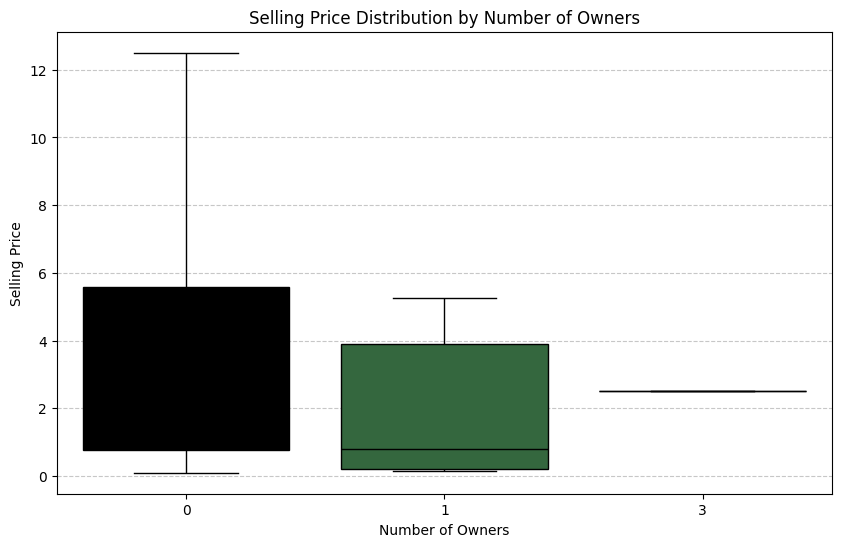

In [51]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Owner', y='Selling_Price', data=df, palette='cubehelix', hue='Owner', legend=False)
plt.title('Selling Price Distribution by Number of Owners')
plt.xlabel('Number of Owners')
plt.ylabel('Selling Price')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Selling Price vs. Kilometers Driven

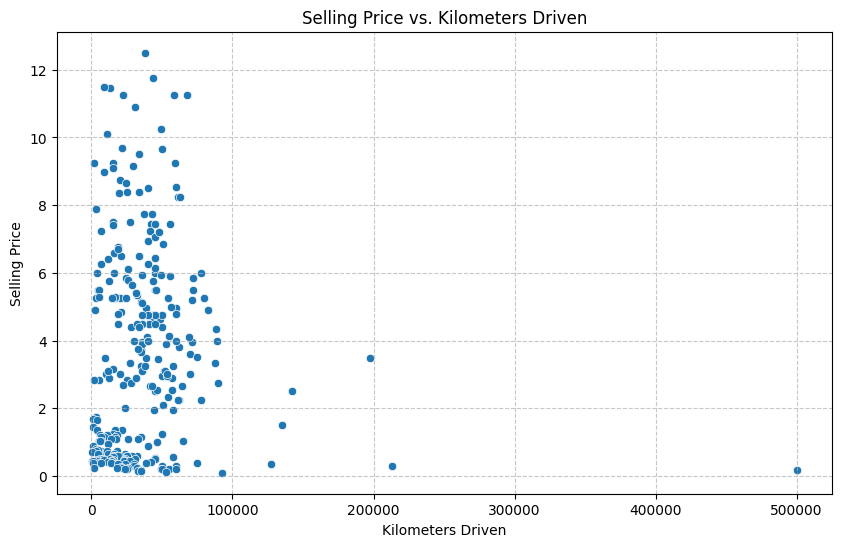

In [52]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Kms_Driven', y='Selling_Price', data=df)
plt.title('Selling Price vs. Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()